In [ ]:
import pandas as pd
import numpy as np


np.random.seed(42)

data = {
    'Age': np.random.randint(18, 70, 500),
    'Income': np.random.randint(20000, 150000, 500),
    'Debt': np.random.randint(0, 50000, 500),
    'Payment_History_Score': np.random.randint(0, 100, 500),
    # Default: 1 ka matlab defaulter (Bad Credit), 0 ka matlab acha customer
    'Default': np.random.choice([0, 1], p=[0.8, 0.2], size=500) 
}

df = pd.DataFrame(data)

df.head()

,Age,Income,Debt,Payment_History_Score,Default
0,56,23343,43088,81,1
1,69,33500,37660,1,0
2,46,73222,39811,0,0
3,32,49375,49289,46,1
4,60,29662,19856,68,1


In [ ]:
# Feature Engineering: 
df['Debt_to_Income_Ratio'] = df['Debt'] / df['Income']

df.head()

,Age,Income,Debt,Payment_History_Score,Default,Debt_to_Income_Ratio
0,56,23343,43088,81,1,1.845864
1,69,33500,37660,1,0,1.124179
2,46,73222,39811,0,0,0.543703
3,32,49375,49289,46,1,0.998258
4,60,29662,19856,68,1,0.669409


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Default', axis=1)

y = df['Default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total rows: {len(df)}")
print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

Total rows: 500
Training rows: 400
Testing rows: 100


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("--- Model Evaluation Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, predictions):.2f}")
print(f"Precision: {precision_score(y_test, predictions):.2f}")
print(f"Recall:    {recall_score(y_test, predictions):.2f}")
print(f"F1-Score:  {f1_score(y_test, predictions):.2f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, predictions):.2f}")

--- Model Evaluation Metrics ---
Accuracy:  0.80
Precision: 0.25
Recall:    0.06
F1-Score:  0.09
ROC-AUC:   0.51


In [ ]:
model_balanced = RandomForestClassifier(class_weight='balanced', random_state=42)

model_balanced.fit(X_train, y_train)

predictions_balanced = model_balanced.predict(X_test)

print("Balanced Model Evaluation Metrics")
print(f"Accuracy:  {accuracy_score(y_test, predictions_balanced):.2f}")
print(f"Precision: {precision_score(y_test, predictions_balanced):.2f}")
print(f"Recall:    {recall_score(y_test, predictions_balanced):.2f}")
print(f"F1-Score:  {f1_score(y_test, predictions_balanced):.2f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, predictions_balanced):.2f}")

Balanced Model Evaluation Metrics
Accuracy:  0.72
Precision: 0.14
Recall:    0.11
F1-Score:  0.12
ROC-AUC:   0.48


In [ ]:
import pandas as pd

file_path = r"g:\OneDrive - University of Engineering and Technology Taxila\Documents\credit_risk_dataset.csv"

real_df = pd.read_csv(file_path)

real_df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
print("--- Data Information ---")
real_df.info()

print("\n--- Missing Values Check ---")
print(real_df.isnull().sum())


--- Data Information ---
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB

--- Missing Values C

In [ ]:
real_df['person_emp_length'] = real_df['person_emp_length'].fillna(real_df['person_emp_length'].median())
real_df['loan_int_rate'] = real_df['loan_int_rate'].fillna(real_df['loan_int_rate'].median())

print("Missing Values Check:")
print(real_df.isnull().sum())

real_df_encoded = pd.get_dummies(real_df, drop_first=True)

print("\nNew Data Shape:", real_df_encoded.shape)

real_df_encoded.head()

Missing Values Check:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

New Data Shape: (32581, 23)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,False,False,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,...,True,False,False,False,True,False,False,False,False,True


In [9]:
print(real_df["loan_status"].value_counts())

print("\nPercentage:")
print(real_df["loan_status"].value_counts(normalize=True) * 100)

loan_status
0    25473
1     7108
Name: count, dtype: int64

Percentage:
loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64


Matplotlib is building the font cache; this may take a moment.


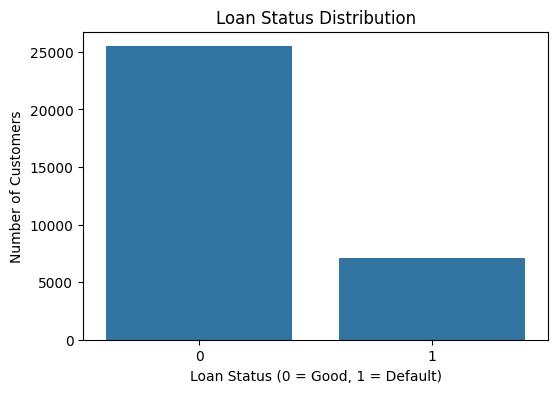

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(data=real_df, x="loan_status")

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status (0 = Good, 1 = Default)")
plt.ylabel("Number of Customers")

plt.show()

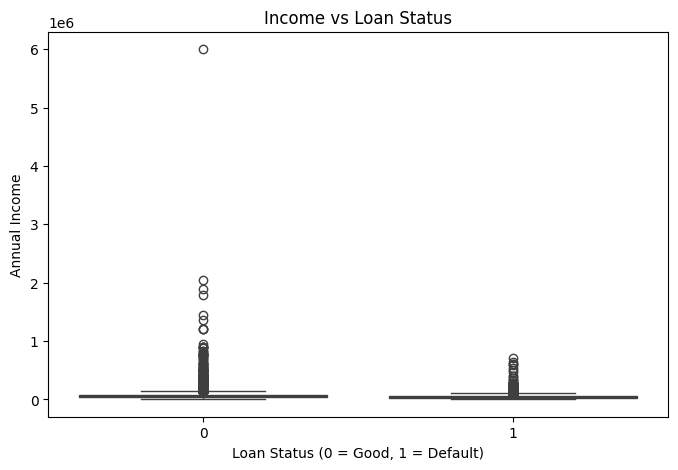

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=real_df,
    x="loan_status",
    y="person_income"
)

plt.title("Income vs Loan Status")
plt.xlabel("Loan Status (0 = Good, 1 = Default)")
plt.ylabel("Annual Income")

plt.show()

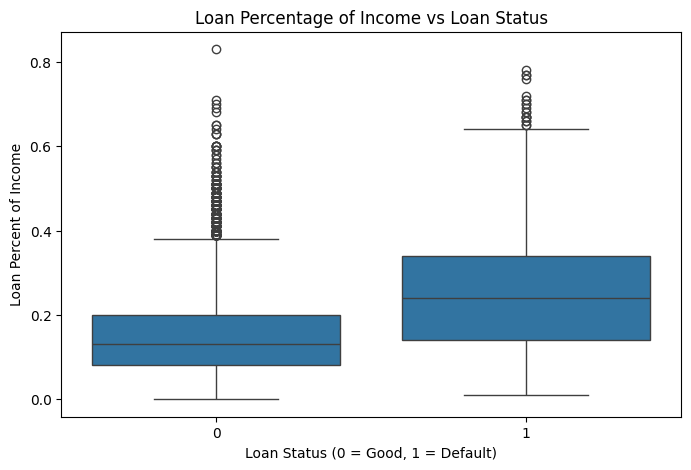

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=real_df,
    x="loan_status",
    y="loan_percent_income"
)

plt.title("Loan Percentage of Income vs Loan Status")
plt.xlabel("Loan Status (0 = Good, 1 = Default)")
plt.ylabel("Loan Percent of Income")

plt.show()

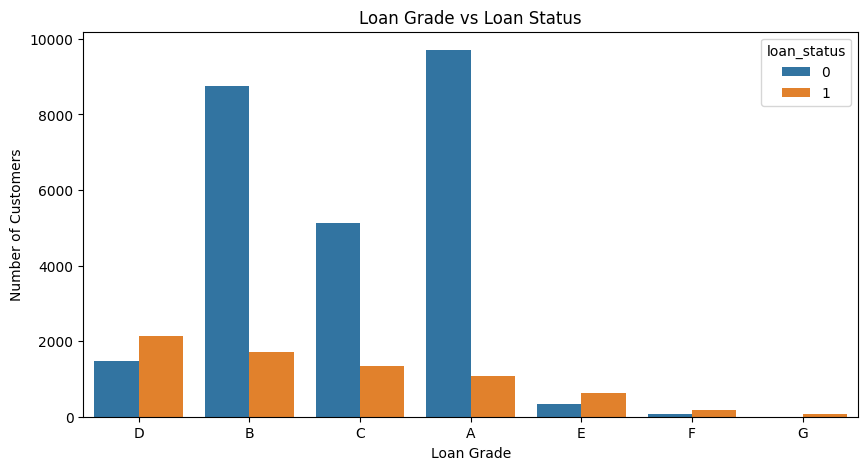

In [13]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=real_df,
    x="loan_grade",
    hue="loan_status"
)

plt.title("Loan Grade vs Loan Status")
plt.xlabel("Loan Grade")
plt.ylabel("Number of Customers")

plt.show()

In [14]:
from sklearn.model_selection import train_test_split

# Features aur Target
X = real_df_encoded.drop("loan_status", axis=1)
y = real_df_encoded["loan_status"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (26064, 22)
Testing Shape: (6517, 22)


In [15]:
from sklearn.ensemble import RandomForestClassifier

# Model banana
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

print("Training model...")

# Training
rf_model.fit(X_train, y_train)

print("Model Training Complete!")

Training model...
Model Training Complete!


In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Predictions
y_pred = rf_model.predict(X_test)

# Metrics
print("----- Model Results -----")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_pred):.4f}")

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

----- Model Results -----
Accuracy : 0.9211
Precision: 0.8790
Recall   : 0.7405
F1 Score : 0.8038
ROC AUC  : 0.8560

Confusion Matrix:
[[4950  145]
 [ 369 1053]]


In [17]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance.head(10))

                        Feature  Importance
5           loan_percent_income    0.197477
1                 person_income    0.168689
4                 loan_int_rate    0.143647
3                     loan_amnt    0.084151
17                 loan_grade_D    0.056204
2             person_emp_length    0.055569
9    person_home_ownership_RENT    0.053508
0                    person_age    0.051692
6    cb_person_cred_hist_length    0.041173
21  cb_person_default_on_file_Y    0.019450


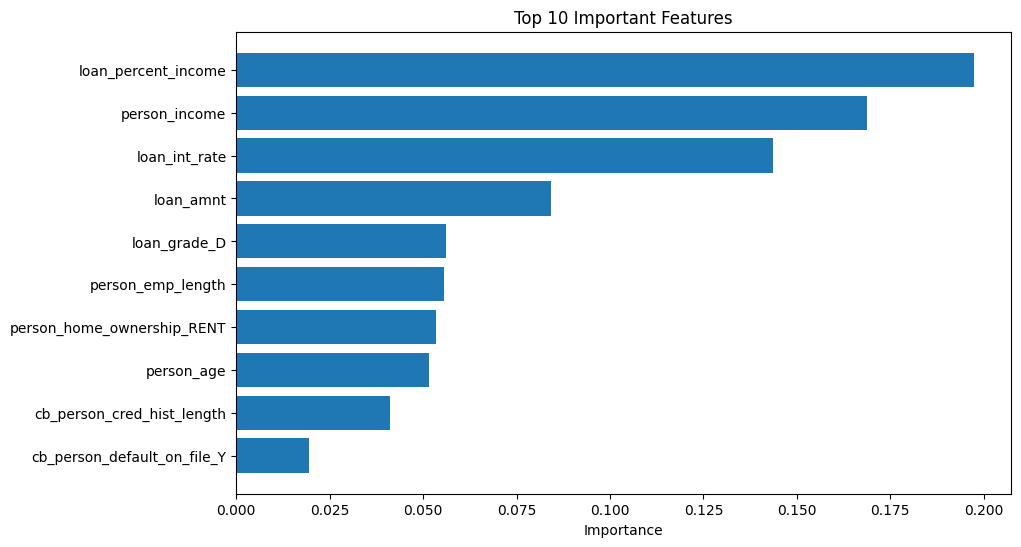

In [18]:
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["Feature"], top10["Importance"])
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      5095
           1       0.88      0.74      0.80      1422

    accuracy                           0.92      6517
   macro avg       0.90      0.86      0.88      6517
weighted avg       0.92      0.92      0.92      6517



In [20]:
import joblib

# Model save
joblib.dump(rf_model, "model.pkl")

# Feature names save
joblib.dump(X_train.columns.tolist(), "features.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!
